In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from datetime import datetime

In [2]:
# configの読み込み
CONFIG_FILE = '../configs/config.yaml'
with open(CONFIG_FILE, encoding="utf-8") as file:
    yml = yaml.safe_load(file)

In [3]:
DIR_INPUT = yml["SETTING"]["DIR_INPUT"]
DIR_INTERIM = yml["SETTING"]["DIR_INTERIM"]
DIR_FEATURE = yml["SETTING"]["DIR_FEATURE"]
DIR_FIGURE = yml["SETTING"]["DIR_FIGURE"]
DIR_HOME = yml["SETTING"]["DIR_HOME"]
DIR_LOG = yml["SETTING"]["DIR_LOG"]
DIR_SUBMISSION = yml["SETTING"]["DIR_SUBMISSION"]
DIR_MODEL = yml["SETTING"]["DIR_MODEL"]
FILE_NAME_STATION = yml["SETTING"]["FILE_NAME_STATION"]
FILE_NAME_STATUS = yml["SETTING"]["FILE_NAME_STATUS"]
FILE_NAME_TRIP = yml["SETTING"]["FILE_NAME_TRIP"]
FILE_NAME_WEATHER = yml["SETTING"]["FILE_NAME_WEATHER"]

In [4]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import TimeseriesModelRunner, MLModelRunner
from src.model_LGBM import model_LGBM_multimodel, model_LGBM_multi_feat
from src.model_LSTM_mult import model_LSTM_mult
from src.model_ASMBL import model_ASMBL_demand_supply_intervention
from src.util import Logger, Util

/Users/ishizuka/opt/anaconda3/envs/mufgcup2024/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# LGBM_台数

In [151]:
# datasetの作成
df_main_lgb_bikes = load_feature("df_key")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_fillna"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_datetime_atr"), on=["datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_weather_feat"), on=["datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_rolling"), on=["station_id", "datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_lr"), on=["station_id", "datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_demand_lag"), on=["station_id", "datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_intervention_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_demand_rolling"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_supply_rolling"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_intervention_rolling"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_demand_lr"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_supply_lr"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_intervention_lr"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_rate_lag"), on=["station_id", "datetime"], how="left")

In [40]:
# datasetの作成
df_main_lgb_bikes = load_feature("df_key")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_trip_fillna"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_is_trip_fillna"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_trip_fillna_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_datetime_atr"), on=["datetime"], how="left")

In [5]:
df_main_lgb_bikes = Util.load_feature("df_key")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, Util.load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, Util.load_feature("df_bikes_available_trip_fillna"), on=["station_id", "datetime"], how="left")

In [6]:
df_main_lgb_bikes.head()

,station_id,datetime,predict,bikes_available
0,0,2013-09-01 00:00:00,0,11.0
1,0,2013-09-01 01:00:00,0,11.0
2,0,2013-09-01 02:00:00,0,11.0
3,0,2013-09-01 03:00:00,0,11.0
4,0,2013-09-01 04:00:00,0,11.0


In [8]:
# df_main_lgb_bikes.to_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_bikes.pkl"))
# df_main_lgb_bikes = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_lgb_new.pkl"))

In [74]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel, model_LGBM_multi_feat

In [7]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lgbm_multimodel_bikes")
# run_name = 'lgbm_multimodel_bikes_202410261847'
run_name

'lgbm_multimodel_bikes_202410262211'

In [8]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left", suffixes=("", "_"))
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    # 1~6時は0時の値をコピー
    df_target = Util.load_feature("df_bikes_available_fillna")
    df_target = df_target[df_target["datetime"].dt.hour == 0]
    df_target["date"] = df_target["datetime"].dt.date
    df_pred["date"] = df_pred["datetime"].dt.date
    df_pred = pd.merge(df_pred, df_target, on=["station_id", "date"], how="left", suffixes=("", "_0"))
    df_pred[target_col] = df_pred.apply(lambda x: x[target_col+"_0"] if x["datetime"].hour<=6 else x[target_col], axis=1)

    return df_pred[["station_id", "datetime", target_col]]

model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    "base_data_name": "df_timefeat_bikes_available_hour", # ユニバース分割時に利用
    # model train params
    "num_boost_round": 5000,
    "early_stopping_rounds": 100,
    "verbose": -1,
    "period": 100,
    'log_level': 'error',
    'verbosity': -1,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    "lambda_l1": 0.1,
    "lambda_l2": 0.1,
    "feature_fraction": 0.8,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [9]:
memo = "LightGBM23期マルチモデル demand_supply追加"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multi_feat,
    model_params_lgb,
    df_main_lgb_bikes,
    run_setting,
    cv_setting,
    logger,
    memo)

In [30]:
# ml_runner.tune_params(30)

In [10]:
ml_runner.run_train_cv()

[2024-10-26 22:23:36] - lgbm_multimodel_bikes_202410262211 - start training cv
[2024-10-26 22:23:37] - lgbm_multimodel_bikes_202410262211 fold 2014-09-01 - start training


max use train date : 2014-08-31 23:00:00
term: 7, tr_x: (22478, 297), tr_y: (22478, 1), va_x: (2170, 297), va_y: (2170, 1)
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.43403	eval's l1: 1.66511
[200]	train's l1: 0.912816	eval's l1: 1.10827
[300]	train's l1: 0.728876	eval's l1: 0.901319
[400]	train's l1: 0.655764	eval's l1: 0.819078
[500]	train's l1: 0.624976	eval's l1: 0.786703
[600]	train's l1: 0.604324	eval's l1: 0.763431
[700]	train's l1: 0.580612	eval's l1: 0.725031
[800]	train's l1: 0.56665	eval's l1: 0.706722
[900]	train's l1: 0.556401	eval's l1: 0.697279
[1000]	train's l1: 0.548245	eval's l1: 0.690562
[1100]	train's l1: 0.542547	eval's l1: 0.686273
[1200]	train's l1: 0.537217	eval's l1: 0.682997
[1300]	train's l1: 0.532005	eval's l1: 0.681142
[1400]	train's l1: 0.526635	eval's l1: 0.679768
[1500]	train's l1: 0.522573	eval's l1: 0.678006
[1600]	train's l1: 0.519356	eval's l1: 0.677362
[1700]	train's l1: 0.516124	eval's l1: 0.676989
[1800]	train

[2024-10-26 22:30:06] - lgbm_multimodel_bikes_202410262211 fold 2014-09-01 - end training
[2024-10-26 22:30:06] - lgbm_multimodel_bikes_202410262211 fold 2014-10-01 - start training


max use train date : 2014-09-30 23:00:00
term: 7, tr_x: (24648, 297), tr_y: (24648, 1), va_x: (420, 297), va_y: (420, 1)
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.45094	eval's l1: 1.73124
[200]	train's l1: 0.925738	eval's l1: 1.22498
[300]	train's l1: 0.742758	eval's l1: 1.05026
[400]	train's l1: 0.6704	eval's l1: 0.975631
[500]	train's l1: 0.636308	eval's l1: 0.941221
[600]	train's l1: 0.604247	eval's l1: 0.890321
[700]	train's l1: 0.584423	eval's l1: 0.856316
[800]	train's l1: 0.571632	eval's l1: 0.832849
[900]	train's l1: 0.56139	eval's l1: 0.81054
[1000]	train's l1: 0.555334	eval's l1: 0.801002
[1100]	train's l1: 0.552122	eval's l1: 0.800165
[1200]	train's l1: 0.548286	eval's l1: 0.798744
[1300]	train's l1: 0.543969	eval's l1: 0.79692
[1400]	train's l1: 0.540403	eval's l1: 0.796023
[1500]	train's l1: 0.537215	eval's l1: 0.795815
[1600]	train's l1: 0.534501	eval's l1: 0.794886
[1700]	train's l1: 0.529494	eval's l1: 0.794889
Early stopping, bes

[2024-10-26 22:35:02] - lgbm_multimodel_bikes_202410262211 fold 2014-10-01 - end training
[2024-10-26 22:35:02] - lgbm_multimodel_bikes_202410262211 fold 2014-11-01 - start training


...

[2024-10-26 23:16:22] - lgbm_multimodel_bikes_202410262211 fold 2015-06-01 - end training
[2024-10-26 23:16:22] - lgbm_multimodel_bikes_202410262211 fold 2015-07-01 - start training


max use train date : 2015-06-30 23:00:00
term: 7, tr_x: (43758, 297), tr_y: (43758, 1), va_x: (280, 297), va_y: (280, 1)
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.60302	eval's l1: 1.9947
[200]	train's l1: 1.0422	eval's l1: 1.54306
[300]	train's l1: 0.821205	eval's l1: 1.29227
[400]	train's l1: 0.724294	eval's l1: 1.19808
[500]	train's l1: 0.682916	eval's l1: 1.17083
[600]	train's l1: 0.660206	eval's l1: 1.14756
[700]	train's l1: 0.648422	eval's l1: 1.13738
[800]	train's l1: 0.638466	eval's l1: 1.12633
[900]	train's l1: 0.631305	eval's l1: 1.12115
[1000]	train's l1: 0.626129	eval's l1: 1.11846
[1100]	train's l1: 0.622059	eval's l1: 1.11559
[1200]	train's l1: 0.618956	eval's l1: 1.1157
Early stopping, best iteration is:
[1123]	train's l1: 0.621121	eval's l1: 1.11527
term: 8, tr_x: (43759, 297), tr_y: (43759, 1), va_x: (280, 297), va_y: (280, 1)
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.84117	eval's l1: 2.4191

[2024-10-26 23:22:51] - lgbm_multimodel_bikes_202410262211 fold 2015-07-01 - end training
[2024-10-26 23:22:51] - lgbm_multimodel_bikes_202410262211 fold 2015-08-01 - start training


max use train date : 2015-07-31 23:00:00
term: 7, tr_x: (45858, 297), tr_y: (45858, 1), va_x: (350, 297), va_y: (350, 1)
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.59683	eval's l1: 1.41524
[200]	train's l1: 1.04553	eval's l1: 0.946096
[300]	train's l1: 0.828681	eval's l1: 0.787698
[400]	train's l1: 0.730591	eval's l1: 0.724076
[500]	train's l1: 0.690797	eval's l1: 0.69825
[600]	train's l1: 0.668074	eval's l1: 0.683937
[700]	train's l1: 0.656781	eval's l1: 0.677392
[800]	train's l1: 0.649576	eval's l1: 0.672877
[900]	train's l1: 0.641019	eval's l1: 0.666672
[1000]	train's l1: 0.635127	eval's l1: 0.662839
[1100]	train's l1: 0.631176	eval's l1: 0.660941
[1200]	train's l1: 0.62739	eval's l1: 0.660778
[1300]	train's l1: 0.62325	eval's l1: 0.658864
[1400]	train's l1: 0.620037	eval's l1: 0.658384
Early stopping, best iteration is:
[1371]	train's l1: 0.620852	eval's l1: 0.658167
term: 8, tr_x: (45859, 297), tr_y: (45859, 1), va_x: (350, 297), va_y: (350, 

[2024-10-26 23:28:34] - lgbm_multimodel_bikes_202410262211 fold 2015-08-01 - end training
[2024-10-26 23:28:34] - lgbm_multimodel_bikes_202410262211 - end training cv


In [ ]:
ml_runner.run_metric_cv()

In [11]:
ml_runner.run_predict_cv()

[2024-10-26 23:28:35] - lgbm_multimodel_bikes_202410262211 - start prediction cv
100%|██████████| 12/12 [02:11<00:00, 10.99s/it]
[2024-10-26 23:30:47] - output predict : ../models/lgbm_multimodel_bikes_202410262211/te_pred.pkl
[2024-10-26 23:30:47] - lgbm_multimodel_bikes_202410262211 - end prediction cv


In [76]:
ml_runner.plot_feature_importance_cv()

[2024-10-26 20:58:14] - lgbm_multimodel_bikes_202410261847 - start plot feature importance cv


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17


[2024-10-26 20:59:00] - lgbm_multimodel_bikes_202410261847 - end plot feature importance cv


In [16]:
# 予測値確認

In [67]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル trend特徴量追加、0時移動特徴量拡張


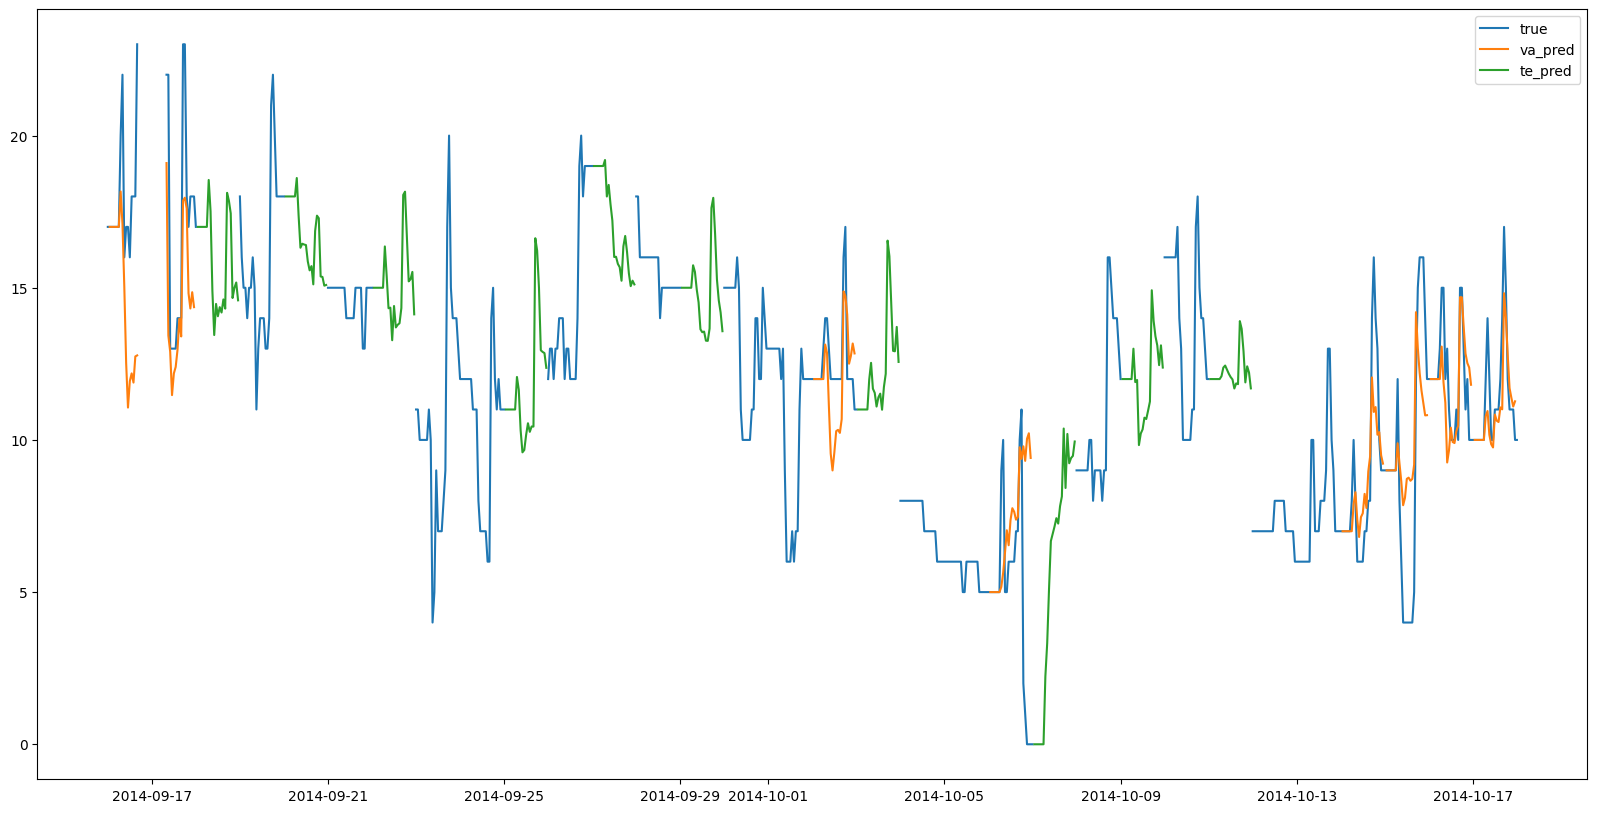

In [68]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LGBM_台数_ユニバース分割

In [77]:
df_main_lgb_bikes_unv1 = pd.concat([Util.load_feature(f"df_timefeat_bikes_available_city_1_hour{h}") for h in range(1,24)], axis=0)
df_main_lgb_bikes_unv2 = pd.concat([Util.load_feature(f"df_timefeat_bikes_available_city_2_hour{h}") for h in range(1,24)], axis=0)
df_main_lgb_bikes_unv3 = pd.concat([Util.load_feature(f"df_timefeat_bikes_available_city_3_hour{h}") for h in range(1,24)], axis=0)
df_main_lgb_bikes_unv4 = pd.concat([Util.load_feature(f"df_timefeat_bikes_available_city_4_hour{h}") for h in range(1,24)], axis=0)
df_main_lgb_bikes_unv5 = pd.concat([Util.load_feature(f"df_timefeat_bikes_available_city_5_hour{h}") for h in range(1,24)], axis=0)

In [129]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel, model_LGBM_multi_feat

In [78]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [79]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm_multimodel_bikes_unv1")
# run_name = 'lgbm_multimodel_bikes_unv1_202410260043'
print(run_name)


def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left", suffixes=("", "_"))
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    # 1~6時は0時の値をコピー
    
    return df_pred

model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    "base_data_name": "df_timefeat_bikes_available_city_2_hour", # ユニバース分割時に利用
    # model train params
    "num_boost_round": 5000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    "lambda_l1": 0.1,
    "lambda_l2": 0.1,
    "feature_fraction": 0.8,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

memo = "LightGBM23期マルチモデル unv1"
ml_runner_unv1 = MLModelRunner(
    run_name,
    model_LGBM_multi_feat,
    model_params_lgb,
    df_main_lgb_bikes_unv1,
    run_setting,
    cv_setting,
    logger,
    memo)

lgbm_multimodel_bikes_unv1_202410262110


In [80]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm_multimodel_bikes_unv2")
# run_name = 'lgbm_multimodel_bikes_unv2_202410260043'
print(run_name)


def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left", suffixes=("", "_"))
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    # 1~6時は0時の値をコピー
    
    return df_pred

model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    "base_data_name": "df_timefeat_bikes_available_city_other_hour", # ユニバース分割時に利用
    # model train params
    "num_boost_round": 5000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    "lambda_l1": 0.1,
    "lambda_l2": 0.1,
    "feature_fraction": 0.8,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

memo = "LightGBM23期マルチモデル unv2"
ml_runner_unv2 = MLModelRunner(
    run_name,
    model_LGBM_multi_feat,
    model_params_lgb,
    df_main_lgb_bikes_unv2,
    run_setting,
    cv_setting,
    logger,
    memo)

lgbm_multimodel_bikes_unv2_202410262110


In [81]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm_multimodel_bikes_unv3")
# run_name = 'lgbm_multimodel_bikes_unv2_202410260043'
print(run_name)


def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left", suffixes=("", "_"))
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    # 1~6時は0時の値をコピー
    
    return df_pred

model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    "base_data_name": "df_timefeat_bikes_available_city_other_hour", # ユニバース分割時に利用
    # model train params
    "num_boost_round": 5000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    "lambda_l1": 0.1,
    "lambda_l2": 0.1,
    "feature_fraction": 0.8,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

memo = "LightGBM23期マルチモデル unv3"
ml_runner_unv3 = MLModelRunner(
    run_name,
    model_LGBM_multi_feat,
    model_params_lgb,
    df_main_lgb_bikes_unv3,
    run_setting,
    cv_setting,
    logger,
    memo)

lgbm_multimodel_bikes_unv3_202410262111


In [82]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm_multimodel_bikes_unv4")
# run_name = 'lgbm_multimodel_bikes_unv2_202410260043'
print(run_name)


def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left", suffixes=("", "_"))
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    # 1~6時は0時の値をコピー
    
    return df_pred

model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    "base_data_name": "df_timefeat_bikes_available_city_other_hour", # ユニバース分割時に利用
    # model train params
    "num_boost_round": 5000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    "lambda_l1": 0.1,
    "lambda_l2": 0.1,
    "feature_fraction": 0.8,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

memo = "LightGBM23期マルチモデル unv4"
ml_runner_unv4 = MLModelRunner(
    run_name,
    model_LGBM_multi_feat,
    model_params_lgb,
    df_main_lgb_bikes_unv4,
    run_setting,
    cv_setting,
    logger,
    memo)

lgbm_multimodel_bikes_unv4_202410262111


In [83]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm_multimodel_bikes_unv5")
# run_name = 'lgbm_multimodel_bikes_unv2_202410260043'
print(run_name)


def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left", suffixes=("", "_"))
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    # 1~6時は0時の値をコピー
    
    return df_pred

model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    "base_data_name": "df_timefeat_bikes_available_city_other_hour", # ユニバース分割時に利用
    # model train params
    "num_boost_round": 5000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    "lambda_l1": 0.1,
    "lambda_l2": 0.1,
    "feature_fraction": 0.8,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

memo = "LightGBM23期マルチモデル unv5"
ml_runner_unv5 = MLModelRunner(
    run_name,
    model_LGBM_multi_feat,
    model_params_lgb,
    df_main_lgb_bikes_unv5,
    run_setting,
    cv_setting,
    logger,
    memo)

lgbm_multimodel_bikes_unv5_202410262112


In [84]:
ml_runner_unv1.run_train_cv()
ml_runner_unv2.run_train_cv()
ml_runner_unv3.run_train_cv()
ml_runner_unv4.run_train_cv()
ml_runner_unv5.run_train_cv()

[2024-10-26 21:12:15] - lgbm_multimodel_bikes_unv1_202410262110 - start training cv
[2024-10-26 21:12:15] - lgbm_multimodel_bikes_unv1_202410262110 fold 2014-09-01 - start training


max use train date : 2014-08-31 23:00:00
term: 7, tr_x: (11547, 159), tr_y: (11547, 1), va_x: (1085, 159), va_y: (1085, 1)
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.77126	eval's l1: 2.04946
[200]	train's l1: 1.13789	eval's l1: 1.39374
[300]	train's l1: 0.941717	eval's l1: 1.17855
[400]	train's l1: 0.876732	eval's l1: 1.11726
[500]	train's l1: 0.844415	eval's l1: 1.09443
[600]	train's l1: 0.824233	eval's l1: 1.08875
[700]	train's l1: 0.810323	eval's l1: 1.08652
[800]	train's l1: 0.798362	eval's l1: 1.085
[900]	train's l1: 0.787943	eval's l1: 1.08418
[1000]	train's l1: 0.777537	eval's l1: 1.08285
[1100]	train's l1: 0.768026	eval's l1: 1.08209
[1200]	train's l1: 0.759562	eval's l1: 1.08173
[1300]	train's l1: 0.75248	eval's l1: 1.08145
[1400]	train's l1: 0.746022	eval's l1: 1.08138
[1500]	train's l1: 0.739453	eval's l1: 1.08084
[1600]	train's l1: 0.732873	eval's l1: 1.08031
[1700]	train's l1: 0.72751	eval's l1: 1.08013
[1800]	train's l1: 0.722288	eva

[2024-10-26 21:15:08] - lgbm_multimodel_bikes_unv1_202410262110 fold 2014-09-01 - end training
[2024-10-26 21:15:08] - lgbm_multimodel_bikes_unv1_202410262110 fold 2014-10-01 - start training


max use train date : 2014-09-30 23:00:00
term: 7, tr_x: (12632, 159), tr_y: (12632, 1), va_x: (210, 159), va_y: (210, 1)
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.78698	eval's l1: 2.14908
[200]	train's l1: 1.15159	eval's l1: 1.58609
[300]	train's l1: 0.956717	eval's l1: 1.429
[400]	train's l1: 0.893681	eval's l1: 1.37533
[500]	train's l1: 0.862759	eval's l1: 1.35163
[600]	train's l1: 0.842001	eval's l1: 1.34985
Early stopping, best iteration is:
[591]	train's l1: 0.843455	eval's l1: 1.34961
term: 8, tr_x: (12632, 159), tr_y: (12632, 1), va_x: (210, 159), va_y: (210, 1)
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 2.15968	eval's l1: 2.99168
[200]	train's l1: 1.76516	eval's l1: 2.63159
[300]	train's l1: 1.63221	eval's l1: 2.4913
[400]	train's l1: 1.565	eval's l1: 2.41574
[500]	train's l1: 1.52233	eval's l1: 2.40619
[600]	train's l1: 1.48917	eval's l1: 2.39806
[700]	train's l1: 1.46193	eval's l1: 2.393
[800]	train'

[2024-10-26 21:18:02] - lgbm_multimodel_bikes_unv1_202410262110 fold 2014-10-01 - end training
[2024-10-26 21:18:03] - lgbm_multimodel_bikes_unv1_202410262110 fold 2014-11-01 - start training


...

[2024-10-26 22:04:19] - lgbm_multimodel_bikes_unv2_202410262110 fold 2014-12-01 - end training
[2024-10-26 22:04:19] - lgbm_multimodel_bikes_unv2_202410262110 fold 2015-01-01 - start training


max use train date : 2014-12-31 23:00:00
term: 7, tr_x: (15201, 134), tr_y: (15201, 1), va_x: (175, 134), va_y: (175, 1)
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.0878	eval's l1: 1.95903
[200]	train's l1: 0.653255	eval's l1: 1.3121
[300]	train's l1: 0.493404	eval's l1: 1.0605
[400]	train's l1: 0.372601	eval's l1: 0.760661
[500]	train's l1: 0.306749	eval's l1: 0.515531
[600]	train's l1: 0.28139	eval's l1: 0.372468
[700]	train's l1: 0.270704	eval's l1: 0.322504
[800]	train's l1: 0.265298	eval's l1: 0.300598
[900]	train's l1: 0.261537	eval's l1: 0.295992
[1000]	train's l1: 0.25919	eval's l1: 0.294943
[1100]	train's l1: 0.256543	eval's l1: 0.294748
Early stopping, best iteration is:
[1062]	train's l1: 0.257788	eval's l1: 0.294581
term: 8, tr_x: (15202, 134), tr_y: (15202, 1), va_x: (175, 134), va_y: (175, 1)
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.1164	eval's l1: 1.81955
[200]	train's l1: 0.744325	eval's l1: 

[2024-10-26 22:09:10] - lgbm_multimodel_bikes_unv2_202410262110 fold 2015-01-01 - end training
[2024-10-26 22:09:10] - lgbm_multimodel_bikes_unv2_202410262110 fold 2015-02-01 - start training


max use train date : 2015-01-31 23:00:00
term: 7, tr_x: (16286, 134), tr_y: (16286, 1), va_x: (245, 134), va_y: (245, 1)
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.13329	eval's l1: 1.2637
[200]	train's l1: 0.649116	eval's l1: 0.739815
[300]	train's l1: 0.485175	eval's l1: 0.57576
[400]	train's l1: 0.358487	eval's l1: 0.382003
[500]	train's l1: 0.302167	eval's l1: 0.303292
[600]	train's l1: 0.280017	eval's l1: 0.275925
[700]	train's l1: 0.270871	eval's l1: 0.264181
[800]	train's l1: 0.263543	eval's l1: 0.257052
[900]	train's l1: 0.259931	eval's l1: 0.253626
[1000]	train's l1: 0.256361	eval's l1: 0.251062
[1100]	train's l1: 0.251661	eval's l1: 0.249991
[1200]	train's l1: 0.248722	eval's l1: 0.249406
[1300]	train's l1: 0.246798	eval's l1: 0.248497
[1400]	train's l1: 0.24514	eval's l1: 0.248265
[1500]	train's l1: 0.243206	eval's l1: 0.247997
Early stopping, best iteration is:
[1482]	train's l1: 0.243569	eval's l1: 0.247684
term: 8, tr_x: (16287, 134),

KeyboardInterrupt: 

In [ ]:
ml_runner_unv1.run_metric_cv()
ml_runner_unv2.run_metric_cv()

In [ ]:
(2.128375664582295 + 0.8811058401089888) / 2

In [ ]:
ml_runner_unv1.run_predict_cv()
ml_runner_unv2.run_predict_cv()

In [ ]:
ml_runner_unv1.plot_feature_importance_cv()
ml_runner_unv2.plot_feature_importance_cv()

In [ ]:
# 予測値確認

In [ ]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[ml_runner.key_cols+[ml_runner.target_col]]

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LSTM_台数

In [ ]:
df_main_lstm_new = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_lstm_new.pkl"))

In [ ]:
df_main_lstm_new

In [ ]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from datetime import datetime
from src.util import Logger

In [ ]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [ ]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [ ]:
logger = Logger(path=DIR_LOG)

In [ ]:
run_name = get_run_name(model_type="lstm_mult")
# run_name = 'lstm_mult_202410132245'
run_name

In [ ]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

In [ ]:
model_params = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "seq_length": 24,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 64,
    "num_epochs": 10,
    "learning_rate": 0.001,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [ ]:
memo = "LSTMのマルチステップ予測 後処理追加"
timeseries_runner = TimeseriesModelRunner(run_name,
                                          model_LSTM_mult,
                                          model_params,
                                          df_main_lstm_new,
                                          run_setting,
                                          cv_setting,
                                          logger,
                                          memo)

In [ ]:
timeseries_runner.run_train_cv()

In [ ]:
timeseries_runner.run_metric_cv()

In [ ]:
timeseries_runner.run_predict_cv()

In [ ]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[timeseries_runner.key_cols+[timeseries_runner.target_col]]

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
# 元の目的関数が欠損している部分（）
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-09-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
# 学習データ数の推移
for month in range(8, 13):
    i_fold = datetime(2014, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = timeseries_runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

for month in range(1, 9):
    i_fold = datetime(2015, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = timeseries_runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

# LGBM_需要

In [169]:

df_main_lgb_demand = load_feature("df_key")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
# df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_demand_cumsum"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_demand"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_demand_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_intervention_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_datetime_atr"), on=["datetime"], how="left")


In [ ]:
df_main_lgb_demand.head()

In [171]:
df_main_lgb_demand.to_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_demand.pkl"))

In [172]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [ ]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_demand")
# run_name = 'lgbm_multiml_demand_202410142258'
run_name

In [174]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(upper=0)

    return df_pred

In [175]:
model_params_lgb_demand = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 3000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_demand = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_demand = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand",
    "initial_fold_date": "2014-09-01",
}

In [176]:
memo = "LightGBM23期マルチモデル demand"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel,
    model_params_lgb_demand,
    df_main_lgb_demand,
    run_setting_lgb_demand,
    cv_setting_lgb_demand,
    logger,
    memo)

In [ ]:
ml_runner.run_train_cv()

In [ ]:
ml_runner.run_metric_cv()

In [ ]:
ml_runner.run_predict_cv()

In [ ]:
ml_runner.plot_feature_importance_cv()

In [181]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_lgb_demand[ml_runner.key_cols+[ml_runner.target_col]]

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LGBM_供給

In [183]:
df_main_lgb_supply = load_feature("df_key")
df_main_lgb_supply = pd.merge(df_main_lgb_supply, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
# df_main_lgb_supply = pd.merge(df_main_lgb_supply, load_feature("df_supply_cumsum"), on=["station_id", "datetime"], how="left")
df_main_lgb_supply = pd.merge(df_main_lgb_supply, load_feature("df_supply"), on=["station_id", "datetime"], how="left")
df_main_lgb_supply = pd.merge(df_main_lgb_supply, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_demand_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_intervention_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_datetime_atr"), on=["datetime"], how="left")

In [184]:
df_main_lgb_supply.to_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_supply.pkl"))

In [185]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [ ]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_supply")
# run_name = 'lgbm_multiml_demand_202410142258'
run_name

In [187]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)

    return df_pred

model_params_lgb_supply = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "supply",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 3000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_supply = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_supply = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "supply",
    "initial_fold_date": "2014-09-01",
}

In [188]:
memo = "LightGBM23期マルチモデル supply"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel,
    model_params_lgb_supply,
    df_main_lgb_supply,
    run_setting_lgb_supply,
    cv_setting_lgb_supply,
    logger,
    memo)

In [ ]:
ml_runner.run_train_cv()

In [ ]:
ml_runner.run_metric_cv()

In [ ]:
ml_runner.run_predict_cv()

In [ ]:
ml_runner.plot_feature_importance_cv()

In [193]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_lgb_supply[ml_runner.key_cols+[ml_runner.target_col]]

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LGBM_介入

In [21]:
df_main_lgb_intervention = load_feature("df_key")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
# df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_intervention_cumsum"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_intervention"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_demand_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_intervention_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_datetime_atr"), on=["datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_bikes_available_rate_lag"), on=["station_id", "datetime"], how="left")

In [22]:
df_main_lgb_intervention.to_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_intervention.pkl"))

In [45]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [ ]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_intervention")
# run_name = 'lgbm_multiml_intervention_202410220039'
run_name

In [46]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """

    return df_pred

model_params_lgb_intervention = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "intervention",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 3000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.001,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_intervention = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_intervention = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "intervention",
    "initial_fold_date": "2014-09-01",
}

In [47]:
memo = "LightGBM23期マルチモデル intervention rmse"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel,
    model_params_lgb_intervention,
    df_main_lgb_intervention,
    run_setting_lgb_intervention,
    cv_setting_lgb_intervention,
    logger,
    memo)

In [ ]:
ml_runner.run_train_cv()

In [ ]:
ml_runner.run_metric_cv()

In [ ]:
ml_runner.run_predict_cv()

In [ ]:
ml_runner.plot_feature_importance_cv()

In [52]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_lgb_intervention[ml_runner.key_cols+[ml_runner.target_col]]

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# 需要＋供給＋介入

In [130]:
def after_predict_process(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

In [66]:
# 各日の00:00からのcumsumに変換
def calc_cumsum_from_00(df_, col):
    df_["date"] = df_["datetime"].dt.date
    df_[f"{col}_cumsum"] = df_.groupby(["station_id", "date"])[col].cumsum()
    df_ = df_.drop(columns=[col, "date"])
    return df_

In [68]:
# de_run_name = "lgbm_multiml_demand_202410210031"
# de_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "va_pred.pkl"))
# de_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "te_pred.pkl"))
# de_va_te_pred = pd.concat([de_va_pred, de_te_pred], axis=0)

# demandをcumsumに変換
de_run_name = "lgbm_multiml_demand_202410212351"
de_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "va_pred.pkl"))
de_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "te_pred.pkl"))
de_va_te_pred = pd.concat([de_va_pred, de_te_pred], axis=0)
de_va_te_pred = calc_cumsum_from_00(de_va_te_pred, "demand")

In [69]:
su_run_name = "lgbm_multiml_supply_202410210121"
su_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "va_pred.pkl"))
su_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "te_pred.pkl"))
su_va_te_pred = pd.concat([su_va_pred, su_te_pred], axis=0)

# supplyをcumsumに変換
su_run_name = "lgbm_multiml_supply_202410220021"
su_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "va_pred.pkl"))
su_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "te_pred.pkl"))
su_va_te_pred = pd.concat([su_va_pred, su_te_pred], axis=0)
su_va_te_pred = calc_cumsum_from_00(su_va_te_pred, "supply")

In [70]:
in_run_name = "lgbm_multiml_intervention_202410210921"
in_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "va_pred.pkl"))
in_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "te_pred.pkl"))
in_va_te_pred = pd.concat([in_va_pred, in_te_pred], axis=0)

# interventionをcumsumに変換
in_run_name = "lgbm_multiml_intervention_202410220902"
in_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "va_pred.pkl"))
in_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "te_pred.pkl"))
in_va_te_pred = pd.concat([in_va_pred, in_te_pred], axis=0)
in_va_te_pred = calc_cumsum_from_00(in_va_te_pred, "intervention")


In [71]:
df_target = load_feature("df_target")
df_true_00 = df_target[df_target["datetime"].dt.hour==0][["station_id", "datetime", "bikes_available"]].copy()
df_true_00["date"] = df_true_00["datetime"].dt.date
df_true_00 = df_true_00.rename(columns={"bikes_available": "bikes_available_00"})
df_true_00 = df_true_00[["station_id", "date", "bikes_available_00"]]
df_pred = load_feature("df_key")
df_pred["date"] = df_pred["datetime"].dt.date
df_pred = pd.merge(df_pred, df_true_00, on=["station_id", "date"], how="left")
df_pred = df_pred[["station_id", "datetime", "bikes_available_00"]]

df_pred = df_pred.copy()
df_pred = pd.merge(df_pred, load_feature("df_predict_add_valid_flag"), on=["station_id","datetime"], how="left")
df_pred = pd.merge(df_pred, de_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_de_va_pred"))
df_pred = pd.merge(df_pred, su_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_su_va_pred"))
df_pred = pd.merge(df_pred, in_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_in_va_pred"))

df_true = df_target[["station_id", "datetime", "bikes_available"]].copy()
df_true = pd.merge(df_true, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")

In [72]:
df_pred["bikes_available"] = df_pred["bikes_available_00"] + df_pred["demand_cumsum"] + df_pred["supply_cumsum"] + df_pred["intervention_cumsum"]

In [73]:
df_metric = pd.merge(df_true, df_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_pred"))
df_metric = df_metric.dropna(subset=["bikes_available", "bikes_available_pred"])
df_metric = df_metric[df_metric["predict"]==2]
df_metric = df_metric.sort_values(["station_id", "datetime"])

In [ ]:
from sklearn.metrics import mean_absolute_error
def metric(va_true, va_pred):
    """評価指標の計算
    """
    score = mean_absolute_error(va_true, va_pred)
    # score = math.sqrt(mean_squared_error(va_true, va_pred))

    return score

metric(df_metric["bikes_available"].values,
       df_metric["bikes_available_pred"].values)

In [ ]:
# datetimeを連続にする
df_ = df_metric.copy()
# データ期間,station_idを指定する
target_col = "bikes_available"
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{target_col}_pred"], label="va_pred")
plt.legend()
plt.show()

# LGBM_需要＋供給＋介入

In [79]:
df_main_lgb_ans = load_feature("df_key")
df_main_lgb_ans = pd.merge(df_main_lgb_ans, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_lgb_ans = pd.merge(df_main_lgb_ans, load_feature("df_bikes_available_fillna"), on=["station_id", "datetime"], how="left")
df_main_lgb_ans = pd.merge(df_main_lgb_ans, pd.read_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_demand.pkl")), on=["station_id", "datetime"], how="left", suffixes=('', '_dem'))
df_main_lgb_ans = pd.merge(df_main_lgb_ans, pd.read_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_supply.pkl")), on=["station_id", "datetime"], how="left", suffixes=('', '_sup'))
df_main_lgb_ans = pd.merge(df_main_lgb_ans, pd.read_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_intervention.pkl")), on=["station_id", "datetime"], how="left", suffixes=('', '_int'))

In [90]:
import importlib
from src import runner
from src import model_LGBM
from src import model_ASMBL
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model_ASMBL)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel
from src.model_LSTM_mult import model_LSTM_mult
from src.model_ASMBL import model_ASMBL_demand_supply_intervention

In [ ]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="ansamble_lgbm")
# run_name = 'ansamble_lgbm_202410162243'
run_name

In [81]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    # pred model params
    "demand_model_cls": model_LGBM_multimodel,
    "supply_model_cls": model_LGBM_multimodel,
    "intervention_model_cls": model_LGBM_multimodel,
    "demand_run_name": "lgbm_multiml_demand_202410212351",
    "supply_run_name": "lgbm_multiml_supply_202410220021",
    "intervention_run_name": "lgbm_multiml_intervention_202410220902",
    # ans model run params
    "num_boost_round": 3000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # ans model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [91]:
memo = "アンサンブルLGBM demand supply interventionの単品をcumsumに変換"
ml_runner = MLModelRunner(
    run_name,
    model_ASMBL_demand_supply_intervention,
    model_params_lgb,
    df_main_lgb_ans,
    run_setting,
    cv_setting,
    logger,
    memo)

In [ ]:
ml_runner.run_train_cv()

In [ ]:
ml_runner.run_metric_cv()

In [ ]:
ml_runner.run_predict_cv()

In [ ]:
ml_runner.plot_feature_importance_cv()

In [141]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[ml_runner.key_cols+[ml_runner.target_col]]

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

# Submissionの作成

In [12]:
runner = ml_runner

In [13]:
path_te_pred = os.path.join(runner.out_dir_name, "te_pred.pkl")
df_te_pred = pd.read_pickle(path_te_pred)
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))[["id", "datetime", "station_id", "predict"]]

In [14]:
df_submit = pd.merge(df_prep_status, df_te_pred, on=["datetime", "station_id"], how="left")

In [15]:
df_sample_submit = pd.read_csv(os.path.join(DIR_INPUT, "sample_submit.csv"), header=None, names=["id", "b_a"])
df_submit = pd.merge(df_sample_submit, df_submit, on=["id"], how="left")[["id", "bikes_available"]]
path_submit = os.path.join(DIR_SUBMISSION, f"{runner.run_name}_submit.csv")
df_submit.to_csv(path_submit, header=False, index=False)
print(path_submit)

../data/submission/lgbm_multimodel_bikes_202410262211_submit.csv


In [73]:
pd.read_csv(path_submit, header=None)

,0,1
0,8761,15.000000
1,8762,15.000000
2,8763,15.000000
3,8764,15.000000
4,8765,15.000000
...,...,...
193195,1226347,10.044561
193196,1226348,10.197374
193197,1226349,9.943622
193198,1226350,10.518210
